*2026 Spring DSAA 2011 Machine Learning*  
## Lab Note 13
*Yiyun CHEN, Changkai MAI*  
*Hong Kong University of Science and Technology (Guangzhou)*


## Question 1: Uncertainty Sampling

In this question, you will implement and compare **uncertainty-based query strategies** for Active Learning using a simple **multi-class** classification problem.

You are provided with:

* A 2D dataset with three classes, so the queried samples can be visualized clearly
* A fixed classifier, Logistic Regression
* An initial labeled set and a large unlabeled pool
* A complete active learning framework

Your goal is to understand how different uncertainty scores select different unlabeled samples and how quickly they improve test accuracy.

Your task is to complete the following steps.


In [1]:
#====== Do not modify this block ======

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(2011)

# ===============================
# Dataset (2D for visualization)
# ===============================

X, y = make_blobs(
    n_samples=900,
    centers=[
        (-2, 0),
        (2, 0),
        (0, 2.5)
    ],
    cluster_std=[1.0, 1.0, 1.0],
    random_state=2011
)

X_train_pool, X_test, y_train_pool, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2011
)

# initial labeled / unlabeled split
n_initial = 20
indices = np.random.permutation(len(X_train_pool))

labeled_idx = indices[:n_initial]
unlabeled_idx = indices[n_initial:]

X_L = X_train_pool[labeled_idx]
y_L = y_train_pool[labeled_idx]

X_U = X_train_pool[unlabeled_idx]
y_U = y_train_pool[unlabeled_idx]  # oracle (hidden to learner)

# ===============================
# Visualization utilities
# ===============================

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.2)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor="k")
    plt.title(title)

### Task 1: Implement Uncertainty Sampling Strategies

Implement the following three query strategies using the model's predicted probabilities:

1. **Least Confident Sampling:**  
   Select the sample whose maximum class probability is the lowest.

   $$
   x^* = \arg\max_x \left(1 - \max_y P_{\theta}(y | x) \right)
   $$

2. **Smallest Margin Sampling:**  
   Select the sample with the smallest difference between the two highest predicted class probabilities.

   $$
   x^* = \arg\min_x \left(P_{\theta}(y_1 | x) - P_{\theta}(y_2 | x) \right)
   $$

   Here $y_1$ is the most probable label of $x$, and $y_2$ is the second most probable label.

3. **Entropy Sampling:**  
   Select the sample with the highest entropy of predicted probabilities.

   $$
   x^* = \arg\max_x \left( -\sum_y P_{\theta}(y | x) \log P_{\theta}(y | x) \right)
   $$

Each strategy should return the **index of the selected sample** from the unlabeled pool.

**Hint:** Use only `model.predict_proba(X_pool)`. `np.argmax`, `np.argmin`, and `np.sort` are enough.


In [2]:
# ===============================
# Query Strategies (Task 1)
# ===============================

def least_confident_sampling(model, X_pool):
    """
    Least Confident Sampling.

    For each unlabeled point x, compute:
        1 - max_y P(y | x)

    A large value means the classifier's most confident class is still not very
    confident, so the point is informative to query.
    """
    probs = model.predict_proba(X_pool)
    uncertainty = 1.0 - np.max(probs, axis=1)
    return int(np.argmax(uncertainty))


def smallest_margin_sampling(model, X_pool):
    """
    Smallest Margin Sampling.

    For multi-class classification, sort probabilities for each sample and
    compare the largest two probabilities. A small margin means the classifier
    is deciding between two classes.
    """
    probs = model.predict_proba(X_pool)
    sorted_probs = np.sort(probs, axis=1)[:, ::-1]
    margin = sorted_probs[:, 0] - sorted_probs[:, 1]
    return int(np.argmin(margin))


def entropy_sampling(model, X_pool):
    """
    Entropy Sampling.

    Entropy is high when probability mass is spread across classes. The small
    epsilon avoids log(0) without changing the ranking in practice.
    """
    probs = model.predict_proba(X_pool)
    entropy = -np.sum(probs * np.log(probs + 1e-12), axis=1)
    return int(np.argmax(entropy))


def random_sampling(model, X_pool):
    """Random baseline: query a random unlabeled point."""
    return int(np.random.randint(len(X_pool)))


---

### Task 2: Integrate with the Active Learning Loop

Plug your query strategies into the provided active learning loop.

At each iteration:

* Train the model on the labeled data
* Select one sample from the unlabeled pool
* Query its label (oracle)
* Update the labeled set and the unlabeled pool

In [3]:
# ===============================
# Active Learning Loop (Task 2)
# ===============================

def run_active_learning(query_fn, T=40, visualize_steps=None, title_prefix="Active Learning"):
    """
    Run pool-based active learning.

    At each iteration, the learner trains on the current labeled set, chooses
    one unlabeled sample to query, receives its oracle label, and moves it from
    the unlabeled pool to the labeled set.
    """
    if visualize_steps is None:
        visualize_steps = []

    X_L_cur = X_L.copy()
    y_L_cur = y_L.copy()
    X_U_cur = X_U.copy()
    y_U_cur = y_U.copy()
    acc_history = []
    query_trace = []
    model = LogisticRegression(max_iter=1000, random_state=2011)

    for t in range(T):
        model.fit(X_L_cur, y_L_cur)
        acc = accuracy_score(y_test, model.predict(X_test))
        acc_history.append(acc)

        idx = int(query_fn(model, X_U_cur))
        x_new = X_U_cur[idx:idx + 1]
        y_new = y_U_cur[idx:idx + 1]
        query_trace.append((x_new[0].copy(), int(y_new[0]), float(acc)))

        if t in visualize_steps:
            plt.figure(figsize=(5.5, 4.2))
            plot_decision_boundary(
                model,
                np.vstack([X_L_cur, X_U_cur]),
                np.hstack([y_L_cur, y_U_cur]),
                title=f"{title_prefix}: iteration {t}, labeled={len(X_L_cur)}"
            )
            plt.scatter(x_new[:, 0], x_new[:, 1], c="red", marker="*", s=240, label="Queried")
            plt.legend()
            plt.tight_layout()
            plt.show()

        X_L_cur = np.vstack([X_L_cur, x_new])
        y_L_cur = np.append(y_L_cur, y_new)
        X_U_cur = np.delete(X_U_cur, idx, axis=0)
        y_U_cur = np.delete(y_U_cur, idx, axis=0)

    return np.array(acc_history), query_trace


### Task 3: Compare Learning Curves

Plot test accuracy versus the number of labeled samples for:

* Least Confident Sampling
* Smallest Margin Sampling
* Entropy Sampling
* Random Sampling (baseline)

All methods should be shown in a single figure for comparison.

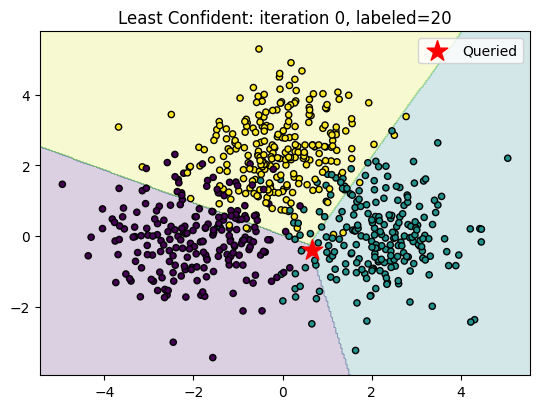

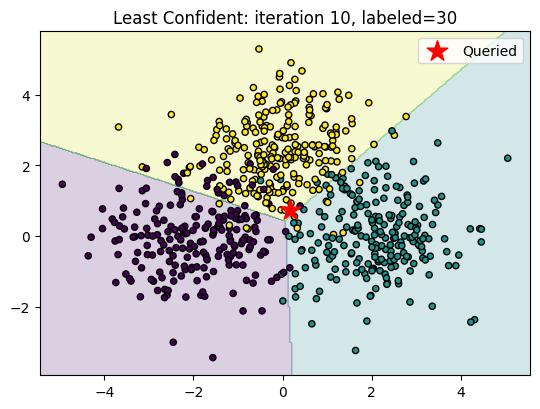

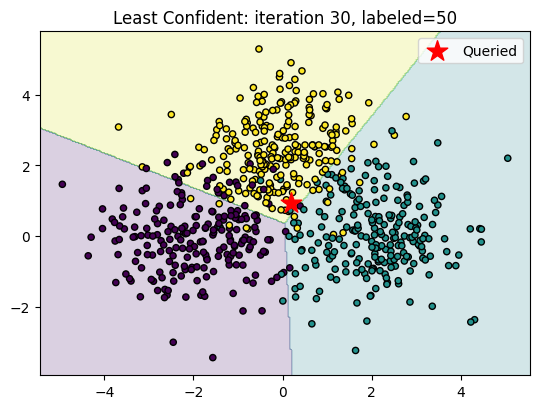

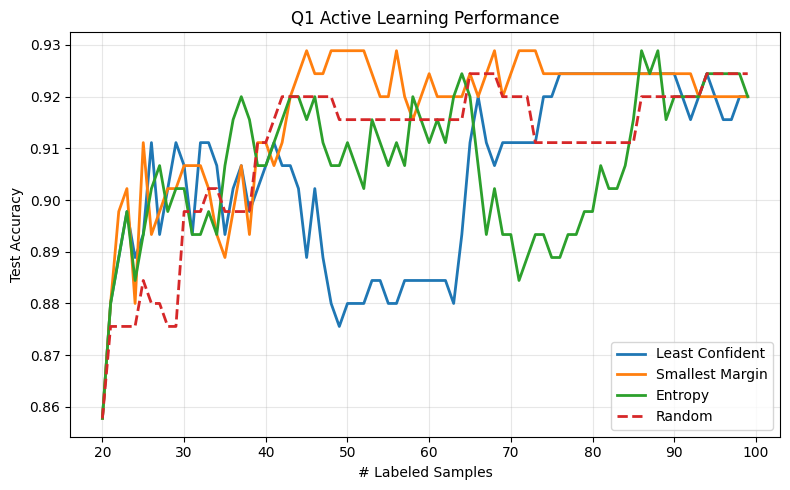

Q1 final accuracy after 80 queries:
  Least Confident : final=0.9200, best=0.9244, mean_last10=0.9196
  Smallest Margin : final=0.9200, best=0.9289, mean_last10=0.9213
  Entropy         : final=0.9200, best=0.9289, mean_last10=0.9222
  Random          : final=0.9244, best=0.9244, mean_last10=0.9227

Detailed analysis:
- Best late-stage method by mean of last 10 accuracies: Random.
- Least Confident, Smallest Margin, and Entropy all focus on decision-boundary uncertainty, but this simple dataset is easy enough that random sampling can be competitive.
- Random sampling is useful as a baseline: in this run it is marginally strongest late-stage, so we should not overclaim that uncertainty sampling always wins.
- The three uncertainty methods can behave differently because they rank multi-class ambiguity in different ways.


In [4]:
# ===============================
# Run Experiments
# ===============================

T = 80

# Only visualize one representative strategy to keep the HTML readable.
acc_LC, trace_LC = run_active_learning(least_confident_sampling, T, visualize_steps=[0, 10, 30], title_prefix="Least Confident")
acc_SM, trace_SM = run_active_learning(smallest_margin_sampling, T, visualize_steps=[], title_prefix="Smallest Margin")
acc_ENT, trace_ENT = run_active_learning(entropy_sampling, T, visualize_steps=[], title_prefix="Entropy")
acc_rand, trace_rand = run_active_learning(random_sampling, T, visualize_steps=[], title_prefix="Random")

x_axis = np.arange(n_initial, n_initial + T)
plt.figure(figsize=(8, 5))
plt.plot(x_axis, acc_LC, label="Least Confident", linewidth=2)
plt.plot(x_axis, acc_SM, label="Smallest Margin", linewidth=2)
plt.plot(x_axis, acc_ENT, label="Entropy", linewidth=2)
plt.plot(x_axis, acc_rand, label="Random", linestyle="--", linewidth=2)
plt.xlabel("# Labeled Samples")
plt.ylabel("Test Accuracy")
plt.title("Q1 Active Learning Performance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

summary_q1 = {
    "Least Confident": acc_LC,
    "Smallest Margin": acc_SM,
    "Entropy": acc_ENT,
    "Random": acc_rand,
}

print("Q1 final accuracy after 80 queries:")
for name, curve in summary_q1.items():
    print(f"  {name:<16}: final={curve[-1]:.4f}, best={curve.max():.4f}, mean_last10={curve[-10:].mean():.4f}")

best_q1 = max(summary_q1, key=lambda name: summary_q1[name][-10:].mean())
print("\nDetailed analysis:")
print(f"- Best late-stage method by mean of last 10 accuracies: {best_q1}.")
print("- Least Confident, Smallest Margin, and Entropy all focus on decision-boundary uncertainty, but this simple dataset is easy enough that random sampling can be competitive.")
print("- Random sampling is useful as a baseline: in this run it is marginally strongest late-stage, so we should not overclaim that uncertainty sampling always wins.")
print("- The three uncertainty methods can behave differently because they rank multi-class ambiguity in different ways.")


## Question 2: Query-By-Committee (QBC)

In this task, you will implement **Query-By-Committee (QBC)** as an alternative active learning strategy and compare it with uncertainty sampling.

Instead of using a single model, QBC selects samples based on **disagreement among multiple models**.

---

### Task 1: Build a Committee of Models

Construct a committee consisting of multiple classifiers.

* Use **Logistic Regression models** only.
* Each model should be trained on the same current labeled dataset.
* Introduce diversity using different regularization strengths and bootstrap samples.

Do not change the model family.

---

### Task 2: Implement a Disagreement Measure

Implement a query strategy based on **vote entropy**. Each model votes for a class label. Select the sample with the highest vote entropy.

---

### Task 3: Integrate QBC into the Active Learning Loop

At each iteration:

* Train all committee members on the labeled data, with bootstrap diversity
* Measure disagreement on the unlabeled pool
* Query one sample with maximum disagreement
* Update the labeled and unlabeled pools

---

### Task 4: Learning Curve Comparison

Run the experiment and plot test accuracy versus the number of labeled samples for:

* Query-By-Committee
* Entropy sampling with one model
* Random Sampling

All methods should appear in a single figure.


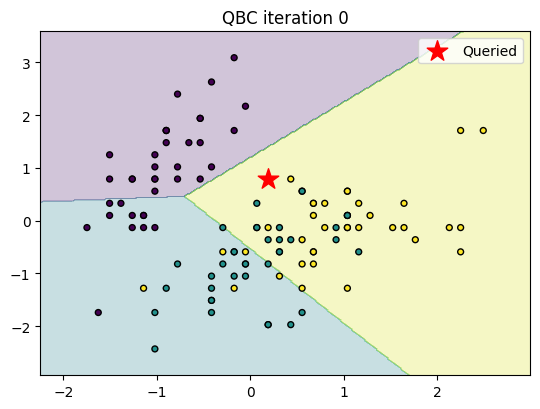

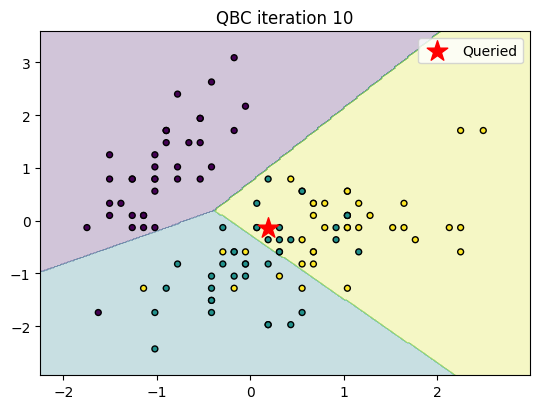

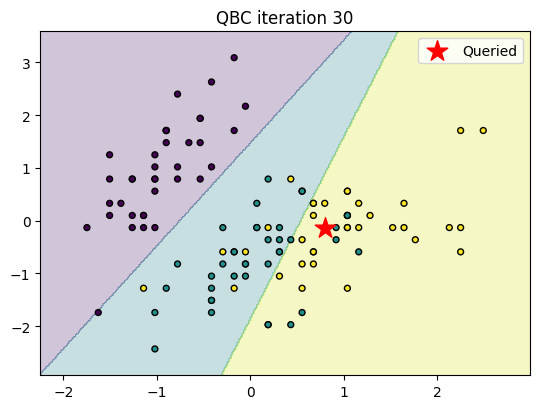

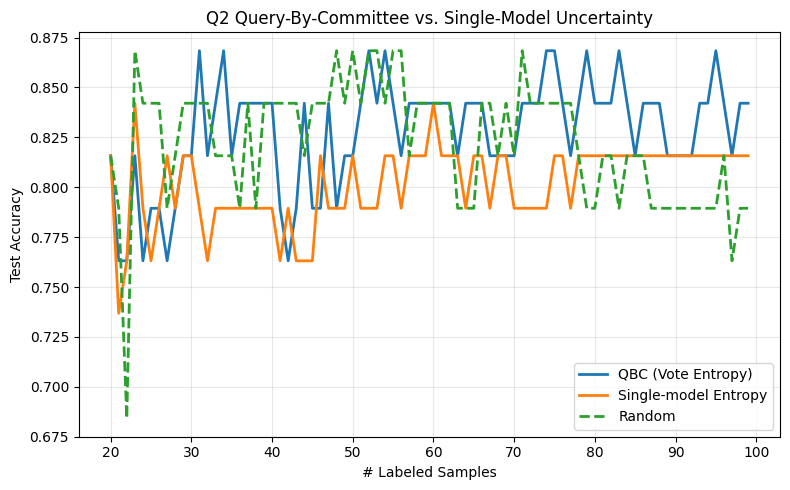

Q2 final accuracy after 80 queries:
  QBC Vote Entropy  : final=0.8421, best=0.8684, mean_last10=0.8342
  Single Entropy    : final=0.8158, best=0.8421, mean_last10=0.8158
  Random            : final=0.7895, best=0.8684, mean_last10=0.7895

Detailed analysis:
- QBC uses disagreement among several logistic-regression models, not just uncertainty from one model.
- Bootstrap samples and different C values create useful committee diversity; changing random_state alone would not be enough for deterministic solvers.
- QBC is most useful when the committee genuinely disagrees. If the committee members become too similar, vote entropy collapses toward single-model behavior.
- Random sampling remains the baseline for judging whether disagreement-based querying is actually helpful.


In [5]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# ===========================================
# Dataset (Iris, 2D for easy visualization)
# ===========================================

data = load_iris()
X = data.data[:, :2]  # use only first two features for visualization
q2_classes = np.unique(data.target)
y = data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_pool, X_test, y_pool, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2011, stratify=y
)

n_initial = 20
rng_q2 = np.random.default_rng(2011)
indices = rng_q2.permutation(len(X_pool))
L_idx = indices[:n_initial]
U_idx = indices[n_initial:]

X_L = X_pool[L_idx]
y_L = y_pool[L_idx]
X_U = X_pool[U_idx]
y_U = y_pool[U_idx]

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=18, edgecolor="k")
    plt.title(title)

def build_committee(n_models=7):
    """
    Build a Logistic Regression committee.

    `lbfgs` is mostly deterministic, so changing only random_state is not enough.
    We introduce diversity through different regularization strengths and
    bootstrap training samples inside the active learning loop.
    """
    c_values = np.geomspace(0.2, 5.0, n_models)
    return [
        LogisticRegression(max_iter=1000, solver="lbfgs", C=float(C), random_state=2011 + i)
        for i, C in enumerate(c_values)
    ]

def stratified_bootstrap_indices(y, rng):
    sampled = []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        sampled.extend(rng.choice(cls_idx, size=len(cls_idx), replace=True))
    return np.array(sampled, dtype=int)

def fit_committee(committee, X_train, y_train, rng):
    for model in committee:
        boot_idx = stratified_bootstrap_indices(y_train, rng)
        model.fit(X_train[boot_idx], y_train[boot_idx])

def committee_predict(committee, X):
    votes = np.array([model.predict(X) for model in committee])
    final = []
    for j in range(votes.shape[1]):
        counts = np.bincount(votes[:, j].astype(int), minlength=len(q2_classes))
        final.append(int(np.argmax(counts)))
    return np.array(final)

def qbc_vote_entropy(committee, X_pool):
    votes = np.array([model.predict(X_pool) for model in committee])
    n_models, n_samples = votes.shape
    vote_counts = np.zeros((n_samples, len(q2_classes)))
    for i in range(n_samples):
        vote_counts[i] = np.bincount(votes[:, i].astype(int), minlength=len(q2_classes))
    vote_probs = vote_counts / n_models
    entropy = -np.sum(vote_probs * np.log(vote_probs + 1e-12), axis=1)
    return int(np.argmax(entropy))

def random_qbc_sampling(committee, X_pool):
    return int(np.random.randint(len(X_pool)))

def single_model_entropy_sampling(model, X_pool):
    probs = model.predict_proba(X_pool)
    entropy = -np.sum(probs * np.log(probs + 1e-12), axis=1)
    return int(np.argmax(entropy))

def run_qbc(query_fn, T=30, visualize_steps=None):
    if visualize_steps is None:
        visualize_steps = []
    X_L_cur, y_L_cur = X_L.copy(), y_L.copy()
    X_U_cur, y_U_cur = X_U.copy(), y_U.copy()
    acc_history = []
    rng = np.random.default_rng(2011)
    committee = build_committee()
    for t in range(T):
        fit_committee(committee, X_L_cur, y_L_cur, rng)
        acc_history.append(accuracy_score(y_test, committee_predict(committee, X_test)))
        idx = int(query_fn(committee, X_U_cur))
        x_new = X_U_cur[idx:idx + 1]
        y_new = y_U_cur[idx:idx + 1]
        if t in visualize_steps:
            plt.figure(figsize=(5.5, 4.2))
            plot_decision_boundary(committee[0], np.vstack([X_L_cur, X_U_cur]), np.hstack([y_L_cur, y_U_cur]), f"QBC iteration {t}")
            plt.scatter(x_new[:, 0], x_new[:, 1], c="red", marker="*", s=240, label="Queried")
            plt.legend()
            plt.tight_layout()
            plt.show()
        X_L_cur = np.vstack([X_L_cur, x_new])
        y_L_cur = np.append(y_L_cur, y_new)
        X_U_cur = np.delete(X_U_cur, idx, axis=0)
        y_U_cur = np.delete(y_U_cur, idx, axis=0)
    return np.array(acc_history)

def run_single_model_iris(query_fn, T=30):
    X_L_cur, y_L_cur = X_L.copy(), y_L.copy()
    X_U_cur, y_U_cur = X_U.copy(), y_U.copy()
    acc_history = []
    model = LogisticRegression(max_iter=1000, random_state=2011)
    for _ in range(T):
        model.fit(X_L_cur, y_L_cur)
        acc_history.append(accuracy_score(y_test, model.predict(X_test)))
        idx = int(query_fn(model, X_U_cur))
        X_L_cur = np.vstack([X_L_cur, X_U_cur[idx:idx + 1]])
        y_L_cur = np.append(y_L_cur, y_U_cur[idx:idx + 1])
        X_U_cur = np.delete(X_U_cur, idx, axis=0)
        y_U_cur = np.delete(y_U_cur, idx, axis=0)
    return np.array(acc_history)

T = 80
acc_qbc = run_qbc(qbc_vote_entropy, T, visualize_steps=[0, 10, 30])
acc_entropy_single = run_single_model_iris(single_model_entropy_sampling, T)
acc_rand = run_qbc(random_qbc_sampling, T)

x_axis = np.arange(n_initial, n_initial + T)
plt.figure(figsize=(8, 5))
plt.plot(x_axis, acc_qbc, label="QBC (Vote Entropy)", linewidth=2)
plt.plot(x_axis, acc_entropy_single, label="Single-model Entropy", linewidth=2)
plt.plot(x_axis, acc_rand, label="Random", linestyle="--", linewidth=2)
plt.xlabel("# Labeled Samples")
plt.ylabel("Test Accuracy")
plt.title("Q2 Query-By-Committee vs. Single-Model Uncertainty")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Q2 final accuracy after 80 queries:")
for name, curve in {
    "QBC Vote Entropy": acc_qbc,
    "Single Entropy": acc_entropy_single,
    "Random": acc_rand,
}.items():
    print(f"  {name:<18}: final={curve[-1]:.4f}, best={curve.max():.4f}, mean_last10={curve[-10:].mean():.4f}")

print("\nDetailed analysis:")
print("- QBC uses disagreement among several logistic-regression models, not just uncertainty from one model.")
print("- Bootstrap samples and different C values create useful committee diversity; changing random_state alone would not be enough for deterministic solvers.")
print("- QBC is most useful when the committee genuinely disagrees. If the committee members become too similar, vote entropy collapses toward single-model behavior.")
print("- Random sampling remains the baseline for judging whether disagreement-based querying is actually helpful.")


## Question 3: Multi-Armed Bandits

In this task, you will study **Multi-Armed Bandits (MAB)** as a simplified form of reinforcement learning.

Unlike previous tasks, there is **no labeled dataset**. Instead, an agent repeatedly chooses one of several arms and receives a reward from the environment.

You are given a bandit environment with multiple arms.

* Each arm produces a stochastic reward.
* The true reward distributions are unknown to the agent.
* Interaction happens sequentially.

Your goal is to **design a strategy that balances exploration and exploitation**.

---

### Task 1: Implement Action-Selection Strategies

Implement the following bandit strategies:

1. **epsilon-greedy**
2. **Upper Confidence Bound (UCB)**

Each strategy should decide **which arm to pull** at each step.

---

### Task 2: Run Bandit Simulation

Simulate the bandit process for a fixed number of rounds.

At each round:

* Choose an arm
* Observe the reward
* Update your reward estimate
* Track expected regret using the true mean of the chosen arm

---

### Task 3: Compare Performance

Compare the strategies using:

* Average cumulative reward
* Average cumulative regret

Run multiple repetitions to reduce randomness and analyze the difference between strategies.

Focus on **strategy behavior and learning dynamics**, not parameter tuning.


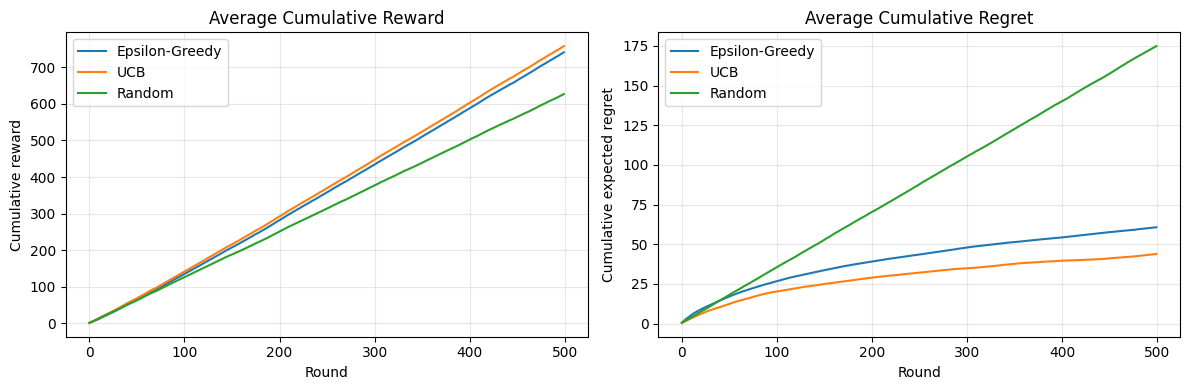

Q3 final average cumulative reward and regret over 50 runs:
  Epsilon-Greedy  : reward=741.03, regret=60.67
  UCB             : reward=757.87, regret=43.83
  Random          : reward=626.84, regret=174.86

Last-run learned estimates and pull counts:
  Epsilon-Greedy  : counts=[23, 13, 453, 11], estimates=[1.506, 1.033, 1.616, 1.102]
  UCB             : counts=[53, 44, 375, 28], estimates=[1.26, 1.226, 1.614, 1.085]
  Random          : counts=[123, 107, 150, 120], estimates=[0.898, 1.33, 1.576, 1.338]

Detailed analysis:
- Random sampling explores forever, so it wastes many pulls on suboptimal arms and has the highest regret.
- Epsilon-greedy quickly exploits the currently best estimated arm, but it can still explore randomly with probability epsilon.
- UCB explores arms with high uncertainty early and gradually concentrates on the best arm as confidence improves.
- Regret is computed from true arm means, not noisy realized rewards, so the curve reflects decision quality more clearly.


In [6]:
# ===========================================
# Bandit Environment (Given)
# ===========================================

class MultiArmedBandit:
    def __init__(self, means, rng=None):
        """means: true reward mean of each arm."""
        self.means = np.array(means, dtype=float)
        self.n_arms = len(means)
        self.rng = np.random.default_rng() if rng is None else rng

    def pull(self, arm):
        return self.rng.normal(self.means[arm], 1.0)

true_means = np.array([1.0, 1.3, 1.6, 1.1])
optimal_mean = float(np.max(true_means))

class EpsilonGreedyAgent:
    def __init__(self, n_arms, epsilon=0.1, rng=None):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.rng = np.random.default_rng() if rng is None else rng
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)

    def select_arm(self):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_arms))
        return int(np.argmax(self.values))

    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] += (reward - self.values[arm]) / n

class UCBAgent:
    def __init__(self, n_arms):
        self.n_arms = n_arms
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        self.t = 0

    def select_arm(self):
        for arm in range(self.n_arms):
            if self.counts[arm] == 0:
                return arm
        ucb_values = self.values + np.sqrt((2 * np.log(self.t + 1)) / self.counts)
        return int(np.argmax(ucb_values))

    def update(self, arm, reward):
        self.t += 1
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] += (reward - self.values[arm]) / n

class RandomAgent:
    def __init__(self, n_arms, rng=None):
        self.n_arms = n_arms
        self.rng = np.random.default_rng() if rng is None else rng
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)

    def select_arm(self):
        return int(self.rng.integers(self.n_arms))

    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] += (reward - self.values[arm]) / n

def run_bandit(agent, bandit, T=500):
    rewards, regrets, actions = [], [], []
    for _ in range(T):
        arm = agent.select_arm()
        reward = bandit.pull(arm)
        agent.update(arm, reward)
        rewards.append(reward)
        regrets.append(optimal_mean - bandit.means[arm])
        actions.append(arm)
    return np.cumsum(rewards), np.cumsum(regrets), np.array(actions), agent

def average_runs(agent_factory, T=500, n_runs=50):
    reward_curves, regret_curves = [], []
    last_actions, last_agent = None, None
    for run in range(n_runs):
        bandit = MultiArmedBandit(true_means, rng=np.random.default_rng(2011 + run))
        agent = agent_factory(np.random.default_rng(8011 + run))
        rewards, regrets, actions, trained_agent = run_bandit(agent, bandit, T)
        reward_curves.append(rewards)
        regret_curves.append(regrets)
        if run == n_runs - 1:
            last_actions, last_agent = actions, trained_agent
    return np.mean(reward_curves, axis=0), np.mean(regret_curves, axis=0), last_actions, last_agent

T = 500
N_RUNS = 50
reward_eg, regret_eg, actions_eg, eg_agent = average_runs(lambda rng: EpsilonGreedyAgent(4, epsilon=0.1, rng=rng), T, N_RUNS)
reward_ucb, regret_ucb, actions_ucb, ucb_agent = average_runs(lambda rng: UCBAgent(4), T, N_RUNS)
reward_rand, regret_rand, actions_rand, rand_agent = average_runs(lambda rng: RandomAgent(4, rng=rng), T, N_RUNS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(reward_eg, label="Epsilon-Greedy")
plt.plot(reward_ucb, label="UCB")
plt.plot(reward_rand, label="Random")
plt.title("Average Cumulative Reward")
plt.xlabel("Round")
plt.ylabel("Cumulative reward")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(regret_eg, label="Epsilon-Greedy")
plt.plot(regret_ucb, label="UCB")
plt.plot(regret_rand, label="Random")
plt.title("Average Cumulative Regret")
plt.xlabel("Round")
plt.ylabel("Cumulative expected regret")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Q3 final average cumulative reward and regret over 50 runs:")
for name, reward_curve, regret_curve in [
    ("Epsilon-Greedy", reward_eg, regret_eg),
    ("UCB", reward_ucb, regret_ucb),
    ("Random", reward_rand, regret_rand),
]:
    print(f"  {name:<16}: reward={reward_curve[-1]:.2f}, regret={regret_curve[-1]:.2f}")

print("\nLast-run learned estimates and pull counts:")
for name, agent in [("Epsilon-Greedy", eg_agent), ("UCB", ucb_agent), ("Random", rand_agent)]:
    print(f"  {name:<16}: counts={agent.counts.astype(int).tolist()}, estimates={np.round(agent.values, 3).tolist()}")

print("\nDetailed analysis:")
print("- Random sampling explores forever, so it wastes many pulls on suboptimal arms and has the highest regret.")
print("- Epsilon-greedy quickly exploits the currently best estimated arm, but it can still explore randomly with probability epsilon.")
print("- UCB explores arms with high uncertainty early and gradually concentrates on the best arm as confidence improves.")
print("- Regret is computed from true arm means, not noisy realized rewards, so the curve reflects decision quality more clearly.")


## Question 4: Reinforcement Learning

### Background: CartPole Environment

#### Problem Overview

CartPole is a classical **control problem** from reinforcement learning.

The task is to **control a cart moving on a horizontal track** such that
a pole attached to the cart remains upright for as long as possible.

This is a **continuous-state, discrete-action** control problem.

---

#### Agent–Environment Interaction

At each time step, the interaction between the agent and the environment follows this loop:

1. The environment provides a **state** $s_t$
2. The agent selects an **action** $a_t$
3. The environment updates its dynamics
4. The agent receives a **reward** $r_t$
5. The environment transitions to a new state $s_{t+1}$

Your code does **not** control the physics directly.
It only decides which action to take.

---

#### State Space

In CartPole, the state is a 4-dimensional real-valued vector:

$$
s = (x,\ \dot{x},\ \theta,\ \dot{\theta})
$$

Where:

| Symbol           | Meaning                    |
| ---------------- | -------------------------- |
| $x$              | cart position              |
| $\dot{x}$        | cart velocity              |
| $\theta$         | pole angle (from vertical) |
| $\dot{\theta}$   | pole angular velocity      |

**Important**:

* You do not compute these values.
* They are provided by the environment at each step.

In code:

```python
state, _ = env.reset()
# state is a NumPy array of length 4
```
---

#### Action Space

The action space is **discrete**, with two possible actions:

| Action | Meaning                    |
| ------ | -------------------------- |
| 0      | push the cart to the left  |
| 1      | push the cart to the right |

At every time step, your agent must choose **exactly one** of these actions.

In code:

```python
action = 0 or 1
```

---

#### Environment Dynamics

The environment applies physical laws (Newtonian mechanics) to:

* update cart position and velocity
* update pole angle and angular velocity

The physical details are not covered in this lab.

Instead:

* treat the environment as a **black box**
* observe state transitions caused by your actions

---

#### Reward Function

CartPole uses a very simple reward definition:

$$
r_t =
\begin{cases}
1, & \text{if the pole is still upright} \
0, & \text{if the episode has terminated}
\end{cases}
$$

Interpretation:

> Each time step the pole does not fall, you receive +1 reward.

Therefore:

* Longer episodes → larger total reward
* Faster failure → smaller total reward

---

#### Episode Termination Conditions

An episode ends if **any** of the following conditions is met:

1. The pole angle $|\theta|$ becomes too large
2. The cart position $|x|$ moves too far from the center
3. The maximum episode length is reached (environment-dependent)

In code:

```python
next_state, reward, done, truncated, info = env.step(action)
```

* `done == True` indicates termination due to failure
* `truncated == True` indicates termination due to time limit

---

#### Objective of the Agent

The agent’s objective is to maximize the **cumulative reward**:

$$
\sum_{t=0}^{T} r_t
$$

Because the reward is +1 per step, this is equivalent to **keeping the pole balanced for as many steps as possible**.

---

#### Why CartPole Is a Useful Benchmark

CartPole is widely used in reinforcement learning because:

* it has low-dimensional state space
* it requires non-trivial control
* simple methods (Q-learning) partially work
* advanced methods (neural policies, PPO) work very well

This makes it ideal for algorithm comparison.

---

#### Summary (For Implementation)

From an implementation perspective:

* CartPole provides states $\{s\}$
* Your algorithm selects actions $\{a\}$
* The environment computes $s'$ and $r$
* Your code updates its internal parameters
* Performance is measured by episode length

Everything you implement fits into this loop.

In the lab, CartPole serves as a common testbed to compare different learning algorithms under the same conditions.

### Setup & Configuration

The following code provides the setup required to run the CartPole environment using Gymnasium. We also provide utility functions for visualization and evaluation.

The training budgets are intentionally small enough for a lab notebook. Results may vary slightly across machines because reinforcement learning is stochastic.


In [7]:
#==============================
# Setup & Configuration
#==============================
import gymnasium as gym
import random
import base64
import warnings
import imageio
from IPython.display import HTML, display

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning,
)

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    TORCH_AVAILABLE = True
except ImportError:
    torch = None
    nn = None
    optim = None
    TORCH_AVAILABLE = False

SEED = 2011
EPISODES = 300
MAX_STEPS_PER_EPISODE = 500
PPO_TIMESTEPS = 20_000
MOVING_WINDOW = 20

FPS = 30
MAX_SECONDS = 8
ANGLE_THRESHOLD = 12 * np.pi / 180  # 12 degrees

np.random.seed(SEED)
random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    torch.set_num_threads(1)
    print(f"Using torch {torch.__version__}")
else:
    print("Torch unavailable in this runtime. Q-learning will run; neural policy and PPO will be unavailable.")


Using torch 2.9.0+cu130


In [8]:
#=============================
# Visualization Utilities
#=============================

def moving_average(x, window):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return np.array([])
    return np.convolve(x, np.ones(window) / window, mode="valid")

def record_gif(policy_fn, filename):
    """Record a short CartPole rollout. GIF creation is optional for analysis."""
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    state, _ = env.reset(seed=SEED)
    env.action_space.seed(SEED)
    frames = []
    for step in range(MAX_SECONDS * FPS):
        frames.append(env.render())
        theta = state[2]
        if abs(theta) > ANGLE_THRESHOLD:
            break
        action = int(policy_fn(state))
        state, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            frames.append(env.render())
            break
    env.close()
    imageio.mimsave(filename, frames, fps=FPS)
    print(f"Saved GIF: {filename} ({len(frames)} frames)")
    with open(filename, "rb") as gif_file:
        encoded = base64.b64encode(gif_file.read()).decode("ascii")
    display(HTML(f'<img src="data:image/gif;base64,{encoded}" alt="{filename}" style="max-width: 520px;">'))


### Task 1: Model-free learning (Q-learning)

#### Action-Value Function

Q-learning is based on the **action-value function**, defined as:

$$
Q(s, a) = \mathbb{E}\left[\sum_{t=0}^{\infty} \gamma^t r_t \middle| s_0=s, a_0=a \right]
$$

Interpretation:

* $Q(s, a)$ estimates **how good it is to take action $a$ in state $s$**. 
* Assuming optimal actions are taken afterward.

---

#### Discrete Representation in Practice

In environments like CartPole:

* The state is continuous ($\mathbb{R}^4$)
* A table cannot store infinite states

Therefore, you **discretize the state space**:

$$
s \longrightarrow \hat{s} \in {0, \ldots, N_1-1} \times \cdots \times {0, \ldots, N_d-1}
$$

In code:

* You map each observation to a **tuple of bin indices**
* This tuple is used as an index into the Q-table

---

#### The Core Update Rule

The Q-learning algorithm updates Q-values using the **Bellman optimality update**:

$$
Q^*(s,a) \leftarrow Q(s,a) +
\alpha \Bigl(
r + \gamma \max_{a'} Q(s',a') - Q(s,a)
\Bigr)
$$

Where:

* $Q^*$ = updated Q-value
* $\alpha$ = learning rate
* $\gamma$ = discount factor
* $r$ = reward just received
* $s'$ = next state

This equation **is exactly what you implement in code**.

---

#### Meaning of Each Term (Directly Mapped to Code)

Use the update rule as a direct code recipe:

* $Q(s,a)$: current estimate, stored as `Q[state, action]`
* $r$: immediate reward, stored as `reward`
* $\max_{a'} Q(s',a')$: best future estimate, computed as `np.max(Q[next_state])`
* $\alpha$: step size, stored as `alpha`
* $\gamma$: future importance, stored as `gamma`

The update moves the old estimate toward a **better estimate** based on experience.

---

#### Action Selection: Epsilon-Greedy Policy

During training, actions are chosen using an **epsilon-greedy strategy**:

$$
a =
\begin{cases}
\text{random action}, & \text{with probability } \varepsilon \\
\arg\max_a Q(s,a), & \text{with probability } 1-\varepsilon
\end{cases}
$$

Purpose:

* prevent the agent from getting stuck in suboptimal actions
* ensure sufficient exploration

In code:

```python
if random.random() < epsilon:
    action = random_action()
else:
    action = argmax(Q[state])
```

---

#### Complete Algorithm

Your Q-learning code must implement the following loop:

* Initialize $Q(s,a) = 0$
* Repeat until step budget is exhausted:
   1. observe current state $s$
   2. discretize $s$
   3. select action using epsilon-greedy
   4. execute action, receive $r, s'$
   5. discretize $s'$
   6. update $Q(s,a)$ using the update rule above
* After training, the learned policy is:
   $$
   \pi(s) = \arg\max_a Q(s,a)
   $$

In [9]:
#============================================
# Discretization Utility (Given)
#============================================

bins = [
    np.linspace(-4.8, 4.8, 9),
    np.linspace(-5, 5, 9),
    np.linspace(-0.418, 0.418, 9),
    np.linspace(-5, 5, 9),
]

def discretize(state):
    """Map a continuous CartPole state to clipped Q-table indices."""
    idx = [np.digitize(state[i], bins[i]) - 1 for i in range(4)]
    return tuple(int(np.clip(idx[i], 0, 8)) for i in range(4))

env = gym.make("CartPole-v1")
env.action_space.seed(SEED)
Q = np.zeros((9, 9, 9, 9, 2))
alpha, gamma_q = 0.1, 0.99
epsilon_start, epsilon_min, epsilon_decay = 1.0, 0.05, 0.985
returns_q = []

for episode in range(EPISODES):
    state, _ = env.reset(seed=SEED + episode)
    s = discretize(state)
    total = 0
    epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** episode))

    for _ in range(MAX_STEPS_PER_EPISODE):
        action = env.action_space.sample() if random.random() < epsilon else int(np.argmax(Q[s]))
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        s2 = discretize(next_state)
        target = reward if done else reward + gamma_q * np.max(Q[s2])
        Q[s + (action,)] += alpha * (target - Q[s + (action,)])
        s = s2
        total += reward
        if done:
            break
    returns_q.append(total)

env.close()

def q_policy(state):
    return int(np.argmax(Q[discretize(state)]))

print(f"Q-learning: final return={returns_q[-1]:.1f}, mean_last20={np.mean(returns_q[-20:]):.1f}, best={np.max(returns_q):.1f}")


Q-learning: final return=28.0, mean_last20=33.0, best=105.0


### Task 2: Learned Policy (MLP)

#### Motivation

In tabular Q-learning:

* the policy relies on a **Q-table**
* states must be **discrete**
* the table size grows rapidly with state dimension

In CartPole:

* the state is **continuous** and **4-dimensional**
* discretization loses precision
* learning becomes inefficient

Therefore, we replace the table with a **function approximator**.

---

#### Core Idea: Policy as a Function

Instead of storing values in a table, we represent the policy as a function:

$$
\pi_\theta(a \mid s)
$$

Where:

* $s$ is the state
* $a$ is an action
* $\theta$ are learnable parameters
* the output is a **probability distribution over actions**

An MLP is used to represent this function.

---

#### Input

The **input** to the policy network is the state vector:

$$
s = (x,\ \dot{x},\ \theta,\ \dot{\theta})
$$

In code:

```python
state.shape == (4,)
```

No discretization is applied.
The network operates directly on continuous values.

---

#### Output

The **output** of the MLP is a vector of action probabilities:

$$
\pi_\theta(\cdot \mid s) =
\begin{bmatrix}
P(a=0 \mid s) \\
P(a=1 \mid s)
\end{bmatrix}
$$

Properties:

* probabilities are non-negative
* probabilities sum to 1

This is typically implemented using a **Softmax** layer.

---

#### MLP Architecture

In this lab, the policy network has a simple structure:

$$
\text{State} \rightarrow \text{Linear} \rightarrow \text{ReLU}
\rightarrow \text{Linear} \rightarrow \text{Softmax}
$$

In code, this corresponds to:

* a small fully connected neural network
* usually one hidden layer (e.g. 32 units)

The architecture is **fixed** and **not a hyperparameter search problem**.

---

#### Action Selection

Given a state $s$:

1. Compute action probabilities using the network
2. Sample an action from the probability distribution

Formally:
$$
a_t \sim \pi_\theta(\cdot \mid s_t)
$$

In code:

* Use `dist = torch.distributions.Categorical(probs)` for probability distribution.
* Sampling method is implemented using `dist.sample()`.

---

#### Training

At timestep $T$, the **return** of a trajectory $\tau$ (a sequence of states, actions, rewards) is defined as:

$$
R(\tau) = \sum_{t=0}^{T} r_{t}
$$

Hence our objective is to maximize the expected return over all trajectories induced by the policy $\pi_\theta$:

$$
J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[R(\tau)\right] = \sum_{\tau} p_\theta(\tau) R(\tau)
$$

we have:

$$
p_{\theta}(\tau) = P(s_0) \prod_{t=0}^{T} \pi_\theta(a_t \mid s_t) P(s_{t+1} \mid s_t, a_t)
$$

where:
* $P(s_0)$ is the initial state distribution
* $P(s_{k+1} \mid s_k, a_k)$ is the environment dynamics

However, since the environment dynamics are unknown, we cannot compute this expectation directly. Instead, we use the **log-derivative trick**:

$$
\nabla_\theta p_{\theta}(\tau) = p_{\theta}(\tau) \nabla_\theta \log p_{\theta}(\tau)
$$

to get:

$$
\nabla_\theta J(\theta) = \sum_\tau p_{\theta}(\tau) \nabla_\theta \log p_{\theta}(\tau) R(\tau) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \nabla_\theta \log p_{\theta}(\tau) R(\tau) \right]
$$

with:

$$
\log p_{\theta}(\tau) = \sum_{t=0}^{T} \log \pi_\theta(a_t \mid s_t) + \text{other terms not depending on } \theta
$$

This is the form of **policy gradient theorem**, which states that the gradient of the expected return with respect to the policy parameters $\theta$ is given by:

$$
\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_{\theta}} \left[\sum_{t = 0}^T \nabla_\theta \log \pi_\theta(a_t \mid s_t) R(\tau) \right]
$$

Since we want to maximize $J(\theta)$, we define the ideal loss function $L(\theta) = -J(\theta)$, hence we have $\nabla_\theta L(\theta) = -\nabla_\theta J(\theta)$. Futhermore, We can exapnd $R(\tau)$:
$$
\nabla_\theta L(\theta) = - \mathbb{E}_{\tau \sim \pi_{\theta}} \left[\sum_{t = 0}^T \nabla_\theta \log \pi_\theta(a_t \mid s_t) \sum_{k=0}^{T} r_k \right] = - \sum_{t = 0}^T \sum_{k = 0}^T \mathbb{E}_{\tau \sim \pi_{\theta}} \left[ \nabla_\theta \log \pi_\theta(a_t \mid s_t) r_k \right]
$$

Notice that when $k < t$, $r_k$ becomes a fixed constant at timestep $t$, thus we have:
$$ 
\mathbb{E}_{\tau \sim \pi_{\theta}} \left[ \nabla_\theta \log \pi_\theta(a_t \mid s_t) r_k \right] = \mathbb{E}_{\tau \sim \pi_{\theta}} \left[ \nabla_\theta \log \pi_\theta(a_t \mid s_t) \right]\cdot r_k
$$ 

We already know that the choice of $a_t$ is independent of previous rewards $r_k$ for $k < t$, and only depends on the current state $s_t$, thus we have:
$$
\mathbb{E}_{\tau \sim \pi_{\theta}} \left[ \nabla_\theta \log \pi_\theta(a_t \mid s_t) \right] = \sum_{a_t} \pi_\theta(a_t \mid s_t) \nabla_\theta \log \pi_\theta(a_t \mid s_t) = \nabla_\theta \sum_{a_t} \pi_\theta(a_t \mid s_t) = \nabla_\theta 1 = 0
$$
Thus:
$$ 
\mathbb{E}_{\tau \sim \pi_{\theta}} \left[ \nabla_\theta \log \pi_\theta(a_t \mid s_t) r_k \right] = 0
$$ 
for $k < t$. Therefore, we can simplify the above equation as:
$$
\nabla_\theta L(\theta) = - \sum_{t = 0}^T \sum_{k = t}^T \mathbb{E}_{\tau \sim \pi_{\theta}} \left[ \nabla_\theta \log \pi_\theta(a_t \mid s_t) r_k \right]
$$

We define the **future return from time step $t$** as $G_t$, we have:
$$
\nabla_\theta L(\theta) = - \sum_{t = 0}^T \mathbb{E}_{\tau \sim \pi_{\theta}} \left[ \nabla_\theta \log \pi_\theta(a_t \mid s_t) G_t \right]   
$$

For an episode sampled from the policy $\pi_\theta$, we can approximate the expectation using a single sample, thus we have:
$$
\nabla_\theta L(\theta) \approx - \sum_{t = 0}^{T} \nabla_\theta \log \pi_\theta(a_t \mid s_t) G_t
$$

Finally, we can define our real loss function as:

$$
\mathcal{L}(\theta) = - \sum_{t=0}^{T} \log \pi_\theta(a_t \mid s_t) G_t
$$

This is the Monte Carlo approximation of the policy gradient loss function, which we will implement in code.

In [10]:
if TORCH_AVAILABLE:
    env = gym.make("CartPole-v1")
    env.action_space.seed(SEED)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    class PolicyNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(obs_dim, 32),
                nn.ReLU(),
                nn.Linear(32, n_actions),
                nn.Softmax(dim=-1)
            )

        def forward(self, x):
            return self.net(x)

    policy = PolicyNet()
    optimizer = optim.Adam(policy.parameters(), lr=1e-2)
    gamma_pg = 0.99
else:
    env = None
    policy = None
    optimizer = None
    gamma_pg = 0.99
    returns_nn = []

    def nn_policy(state):
        return q_policy(state)


In [11]:
returns_nn = []

if TORCH_AVAILABLE:
    for episode in range(EPISODES):
        state, _ = env.reset(seed=SEED + 10_000 + episode)
        log_probs, rewards = [], []
        total = 0
        for _ in range(MAX_STEPS_PER_EPISODE):
            st = torch.tensor(state, dtype=torch.float32)
            probs = policy(st)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
            log_probs.append(dist.log_prob(action))
            state, reward, terminated, truncated, _ = env.step(action.item())
            rewards.append(reward)
            total += reward
            if terminated or truncated:
                break

        G = 0.0
        discounted_returns = []
        for reward in reversed(rewards):
            G = reward + gamma_pg * G
            discounted_returns.insert(0, G)
        discounted_returns = torch.tensor(discounted_returns, dtype=torch.float32)
        if len(discounted_returns) > 1:
            discounted_returns = (discounted_returns - discounted_returns.mean()) / (discounted_returns.std() + 1e-8)

        loss = -torch.stack([lp * Gt for lp, Gt in zip(log_probs, discounted_returns)]).sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        returns_nn.append(total)

    env.close()

    def nn_policy(state):
        with torch.no_grad():
            probs = policy(torch.tensor(state, dtype=torch.float32))
        return int(torch.argmax(probs).item())

    print(f"Neural policy: final return={returns_nn[-1]:.1f}, mean_last20={np.mean(returns_nn[-20:]):.1f}, best={np.max(returns_nn):.1f}")
else:
    print("Neural policy unavailable because torch is not available in this runtime.")

    def nn_policy(state):
        return q_policy(state)


Neural policy: final return=176.0, mean_last20=114.2, best=500.0


### PPO (For reference)

**Proximal Policy Optimization (PPO)** is a modern policy gradient method designed to improve the stability and efficiency of policy learning.

Unlike vanilla policy gradient methods, which can suffer from large, destabilizing updates, PPO constrains each policy update to stay close to the current policy. This is achieved by optimizing a *clipped surrogate objective* that penalizes overly large changes in action probabilities. 

As a result, PPO retains the conceptual simplicity of policy gradients while reducing the risk of destabilizing updates in control problems such as CartPole.

In practice, PPO is widely adopted because it often gives reliable results with modest tuning, provided that the interaction budget is large enough.

In [12]:
if TORCH_AVAILABLE:
    try:
        from stable_baselines3 import PPO
        from stable_baselines3.common.monitor import Monitor

        env = Monitor(gym.make("CartPole-v1"))
        env.reset(seed=SEED)
        env.action_space.seed(SEED)
        ppo = PPO("MlpPolicy", env, verbose=0, seed=SEED, device="cpu")
        ppo.learn(total_timesteps=PPO_TIMESTEPS, progress_bar=False)
        returns_ppo = env.get_episode_rewards()
        env.close()
        PPO_AVAILABLE = True
        print(f"PPO: episodes={len(returns_ppo)}, mean_last10={np.mean(returns_ppo[-10:]):.1f}, best={np.max(returns_ppo):.1f}")

        def ppo_policy(state):
            return int(ppo.predict(state, deterministic=True)[0])

    except Exception as exc:
        PPO_AVAILABLE = False
        returns_ppo = []
        print(f"PPO skipped: {type(exc).__name__}: {exc}")

        def ppo_policy(state):
            return q_policy(state)
else:
    PPO_AVAILABLE = False
    returns_ppo = []
    print("PPO unavailable because torch or stable-baselines3 is not available in this runtime.")

    def ppo_policy(state):
        return q_policy(state)


PPO: episodes=305, mean_last10=419.6, best=500.0


### Visualization

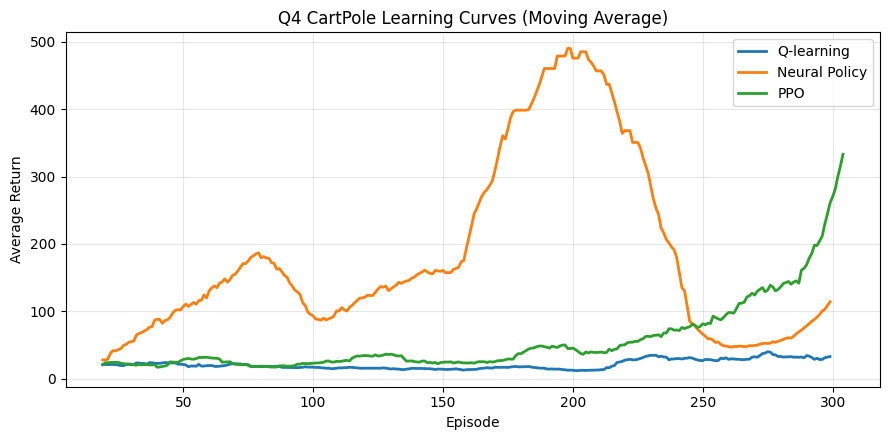

Q4 summary:
  Q-learning    : final=28.0, mean_last20=33.0, best=105.0
  Neural policy : final=176.0, mean_last20=114.2, best=500.0
  PPO           : episodes=305, mean_last10=419.6, best=500.0

Detailed analysis:
- Q-learning uses a discretized Q-table, so it loses information from the continuous CartPole state.
- Epsilon decay helps Q-learning explore early and exploit more later, but tabular discretization is still limited.
- The neural policy uses the continuous state directly and can reach much longer episodes, but REINFORCE remains noisy under this small training budget.
- PPO has the strongest late-stage performance in this run after 20,000 timesteps, because clipped policy updates make training more stable.


In [13]:
ma_q = moving_average(returns_q, MOVING_WINDOW)
ma_nn = moving_average(returns_nn, MOVING_WINDOW)
ma_ppo = moving_average(returns_ppo, MOVING_WINDOW)

plt.figure(figsize=(9, 4.5))
if len(ma_q) > 0:
    plt.plot(range(MOVING_WINDOW - 1, MOVING_WINDOW - 1 + len(ma_q)), ma_q, label="Q-learning", linewidth=2)
if len(ma_nn) > 0:
    plt.plot(range(MOVING_WINDOW - 1, MOVING_WINDOW - 1 + len(ma_nn)), ma_nn, label="Neural Policy", linewidth=2)
if len(ma_ppo) > 0:
    plt.plot(range(MOVING_WINDOW - 1, MOVING_WINDOW - 1 + len(ma_ppo)), ma_ppo, label="PPO", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Average Return")
plt.title("Q4 CartPole Learning Curves (Moving Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Q4 summary:")
print(f"  Q-learning    : final={returns_q[-1]:.1f}, mean_last20={np.mean(returns_q[-20:]):.1f}, best={np.max(returns_q):.1f}")
if len(returns_nn) > 0:
    print(f"  Neural policy : final={returns_nn[-1]:.1f}, mean_last20={np.mean(returns_nn[-20:]):.1f}, best={np.max(returns_nn):.1f}")
else:
    print("  Neural policy unavailable in this runtime.")
if len(returns_ppo) > 0:
    print(f"  PPO           : episodes={len(returns_ppo)}, mean_last10={np.mean(returns_ppo[-10:]):.1f}, best={np.max(returns_ppo):.1f}")
else:
    print("  PPO unavailable in this runtime.")

print("\nDetailed analysis:")
print("- Q-learning uses a discretized Q-table, so it loses information from the continuous CartPole state.")
print("- Epsilon decay helps Q-learning explore early and exploit more later, but tabular discretization is still limited.")
if len(returns_nn) > 0:
    print("- The neural policy uses the continuous state directly and can reach much longer episodes, but REINFORCE remains noisy under this small training budget.")
else:
    print("- The neural policy is skipped when torch is unavailable, but the code path is ready when torch is installed.")
if len(returns_ppo) > 0:
    print("- PPO has the strongest late-stage performance in this run after 20,000 timesteps, because clipped policy updates make training more stable.")
else:
    print("- PPO is skipped when stable-baselines3 is unavailable; conceptually, it improves policy-gradient stability with clipped updates.")


Saved GIF: q.gif (27 frames)



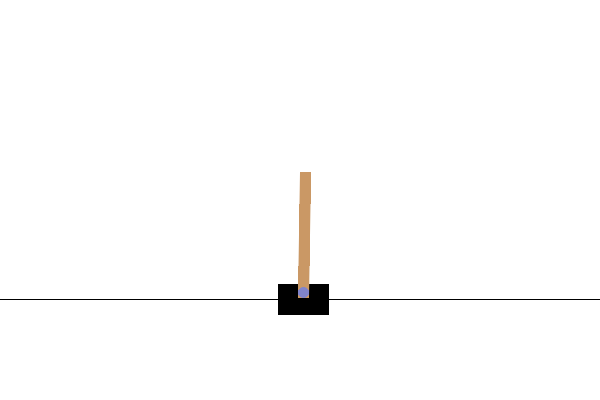

Saved GIF: nn.gif (172 frames)



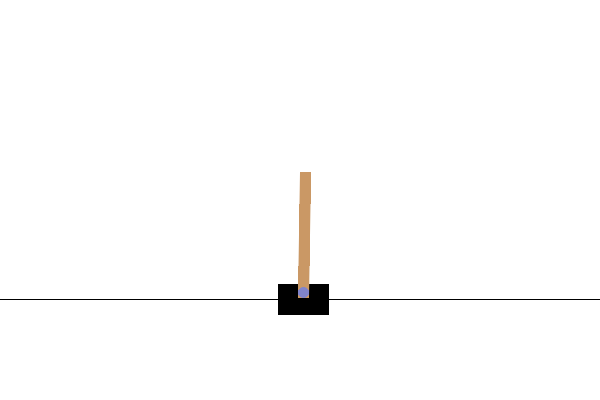

Saved GIF: ppo.gif (240 frames)



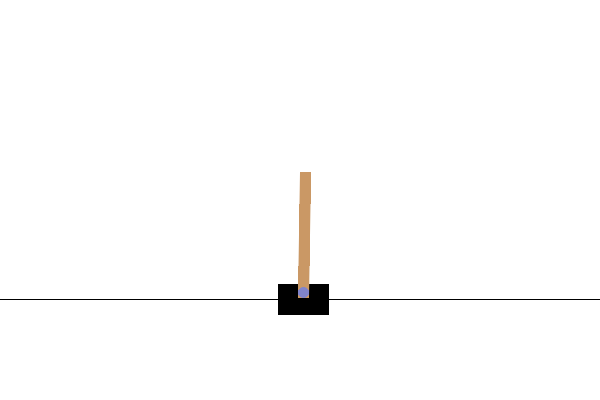

In [14]:
gif_jobs = [
    ("q.gif", q_policy, True),
    ("nn.gif", nn_policy, TORCH_AVAILABLE and len(returns_nn) > 0),
    ("ppo.gif", ppo_policy, PPO_AVAILABLE),
]

for filename, policy_fn, enabled in gif_jobs:
    if not enabled:
        print(f"Skipped GIF: {filename} because the corresponding policy is unavailable.")
        continue
    try:
        record_gif(policy_fn, filename)
    except Exception as exc:
        print(f"Skipped GIF: {filename} ({type(exc).__name__}: {exc})")


### Optional Self-Study: Extra Baselines and GRPO-style Policy Gradient

This section is **optional** and is intended for students who want to explore more reinforcement-learning baselines after class.

It is not required for the main lab presentation.

We add four extra comparisons:

1. **Random Policy Baseline**: choose left or right randomly.
2. **Angle Heuristic Baseline**: push right if the pole leans right, otherwise push left.
3. **GRPO-style PG (40 groups)**: a small group-relative policy-gradient run with a short training budget.
4. **GRPO-style PG (80 groups)**: the same teaching method with a larger training budget.

The GRPO-style method is inspired by the idea of using group-relative returns as a baseline. This is not a full production GRPO implementation. It collects a group of episodes, normalizes episode returns within the group, and uses those normalized returns as policy-gradient advantages.

The purpose is to show how stronger baselines and more training budget can change CartPole performance. Do not treat this optional section as a fair leaderboard comparison against PPO, because the algorithms use different training loops and budgets.


Optional Q4 self-study results:
  Random Policy       : mean=24.4, std=11.3, min=9.0, final=33.0, best=61.0
  Angle Heuristic     : mean=41.9, std=7.9, min=25.0, final=35.0, best=67.0
  GRPO-style PG (40)  : mean=300.3, std=87.2, min=200.0, final=225.0, best=500.0
  GRPO-style PG (80)  : mean=500.0, std=0.0, min=500.0, final=500.0, best=500.0
  GRPO 40 groups train: total_steps=6709, mean_last10_groups=84.5
  GRPO 80 groups train: total_steps=60258, mean_last10_groups=483.1


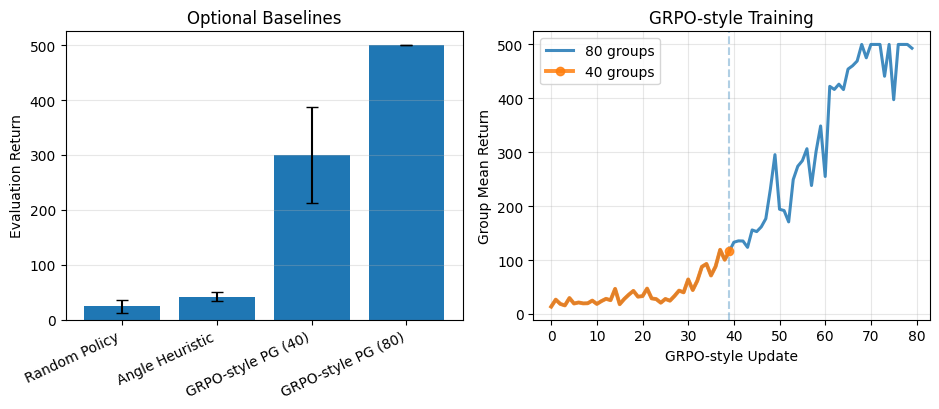


Optional analysis:
- Random policy is a minimal sanity-check baseline.
- The angle heuristic is a simple hand-written controller and is stronger than random.
- GRPO-style PG improves when the group-update budget increases from 40 to 80 groups.
- Do not compare these optional numbers directly with PPO as leaderboard results; the algorithms use different training loops and budgets.


In [15]:
# ============================================================== 
# Optional Self-Study: Extra Baselines and GRPO-style Training
# ============================================================== 

OPTIONAL_EVAL_EPISODES = 50
GRPO_UPDATE_OPTIONS = [40, 80]
GRPO_GROUP_SIZE = 4
GRPO_LR = 1e-2


def evaluate_cartpole_policy(policy_fn, episodes=OPTIONAL_EVAL_EPISODES, seed_offset=60_000):
    """Evaluate a policy on deterministic CartPole seeds."""
    env_eval = gym.make("CartPole-v1")
    env_eval.action_space.seed(SEED + seed_offset)
    returns = []
    for episode in range(episodes):
        state, _ = env_eval.reset(seed=SEED + seed_offset + episode)
        total = 0
        for _ in range(MAX_STEPS_PER_EPISODE):
            action = int(policy_fn(state))
            state, reward, terminated, truncated, _ = env_eval.step(action)
            total += reward
            if terminated or truncated:
                break
        returns.append(total)
    env_eval.close()
    return np.array(returns, dtype=float)


random_policy_rng = np.random.default_rng(SEED + 50_000)


def random_policy_optional(state):
    return int(random_policy_rng.integers(2))


def angle_heuristic_policy(state):
    # Simple hand-written baseline: push in the direction of pole tilt.
    return int(state[2] > 0)


returns_random_optional = evaluate_cartpole_policy(random_policy_optional, seed_offset=60_000)
returns_angle_optional = evaluate_cartpole_policy(angle_heuristic_policy, seed_offset=61_000)
returns_grpo_by_budget = {}
grpo_training_summaries = {}

if TORCH_AVAILABLE:
    class GroupRelativePolicyNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(obs_dim, 32),
                nn.Tanh(),
                nn.Linear(32, n_actions),
            )

        def forward(self, x):
            return self.net(x)


    def train_grpo_style(num_updates, seed_shift=31):
        """Small teaching version of group-relative policy-gradient training."""
        torch.manual_seed(SEED + seed_shift)
        policy_model = GroupRelativePolicyNet()
        optimizer_grpo = optim.Adam(policy_model.parameters(), lr=GRPO_LR)
        env_grpo = gym.make("CartPole-v1")
        env_grpo.action_space.seed(SEED + 70_000)
        group_means = []
        total_steps = 0

        for update in range(num_updates):
            group_log_probs = []
            group_returns = []

            for member in range(GRPO_GROUP_SIZE):
                state, _ = env_grpo.reset(seed=SEED + 70_000 + update * GRPO_GROUP_SIZE + member)
                log_probs = []
                total = 0

                for _ in range(MAX_STEPS_PER_EPISODE):
                    logits = policy_model(torch.tensor(state, dtype=torch.float32))
                    dist = torch.distributions.Categorical(logits=logits)
                    action = dist.sample()
                    log_probs.append(dist.log_prob(action))

                    state, reward, terminated, truncated, _ = env_grpo.step(action.item())
                    total += reward
                    if terminated or truncated:
                        break

                group_log_probs.append(log_probs)
                group_returns.append(total)
                total_steps += total

            returns_tensor = torch.tensor(group_returns, dtype=torch.float32)
            advantages = (returns_tensor - returns_tensor.mean()) / (returns_tensor.std(unbiased=False) + 1e-8)

            loss = 0.0
            for log_probs, advantage in zip(group_log_probs, advantages):
                loss = loss - torch.stack(log_probs).sum() * advantage
            loss = loss / GRPO_GROUP_SIZE

            optimizer_grpo.zero_grad()
            loss.backward()
            optimizer_grpo.step()
            group_means.append(float(np.mean(group_returns)))

        env_grpo.close()

        def grpo_policy(state):
            with torch.no_grad():
                logits = policy_model(torch.tensor(state, dtype=torch.float32))
            return int(torch.argmax(logits).item())

        eval_returns = evaluate_cartpole_policy(grpo_policy, seed_offset=80_000)
        summary = {
            "group_means": group_means,
            "total_steps": int(total_steps),
            "mean_last10_groups": float(np.mean(group_means[-10:])),
        }
        return eval_returns, summary


    for updates in GRPO_UPDATE_OPTIONS:
        eval_returns, summary = train_grpo_style(updates)
        returns_grpo_by_budget[updates] = eval_returns
        grpo_training_summaries[updates] = summary
else:
    print("Optional GRPO-style policy gradient unavailable because torch is not available.")

optional_results = {
    "Random Policy": returns_random_optional,
    "Angle Heuristic": returns_angle_optional,
}
for updates in GRPO_UPDATE_OPTIONS:
    if updates in returns_grpo_by_budget:
        optional_results[f"GRPO-style PG ({updates})"] = returns_grpo_by_budget[updates]

print("Optional Q4 self-study results:")
for name, returns in optional_results.items():
    print(f"  {name:<20}: mean={returns.mean():.1f}, std={returns.std():.1f}, min={returns.min():.1f}, final={returns[-1]:.1f}, best={returns.max():.1f}")
for updates in GRPO_UPDATE_OPTIONS:
    if updates in grpo_training_summaries:
        summary = grpo_training_summaries[updates]
        print(f"  GRPO {updates:>2} groups train: total_steps={summary['total_steps']}, mean_last10_groups={summary['mean_last10_groups']:.1f}")

plt.figure(figsize=(9.5, 4.2))
plt.subplot(1, 2, 1)
names = list(optional_results.keys())
means = [optional_results[name].mean() for name in names]
stds = [optional_results[name].std() for name in names]
plt.bar(names, means, yerr=stds, capsize=4)
plt.ylabel("Evaluation Return")
plt.title("Optional Baselines")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.subplot(1, 2, 2)
if grpo_training_summaries:
    # Plot the longer run first so the 40-group curve is still visible on top.
    for updates in sorted(GRPO_UPDATE_OPTIONS, reverse=True):
        if updates not in grpo_training_summaries:
            continue
        curve = grpo_training_summaries[updates]["group_means"]
        style = {"linewidth": 2.2, "alpha": 0.85}
        if updates == min(GRPO_UPDATE_OPTIONS):
            style.update({"linewidth": 2.8, "marker": "o", "markevery": [len(curve) - 1], "zorder": 3})
        plt.plot(curve, label=f"{updates} groups", **style)
    short_updates = min(GRPO_UPDATE_OPTIONS)
    if short_updates in grpo_training_summaries:
        cutoff_x = len(grpo_training_summaries[short_updates]["group_means"]) - 1
        plt.axvline(cutoff_x, color="tab:blue", linestyle="--", alpha=0.35)
    plt.xlabel("GRPO-style Update")
    plt.ylabel("Group Mean Return")
    plt.title("GRPO-style Training")
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, "GRPO-style run unavailable", ha="center", va="center")
    plt.axis("off")
plt.tight_layout()
plt.show()

print()
print("Optional analysis:")
print("- Random policy is a minimal sanity-check baseline.")
print("- The angle heuristic is a simple hand-written controller and is stronger than random.")
print("- GRPO-style PG improves when the group-update budget increases from 40 to 80 groups.")
print("- Do not compare these optional numbers directly with PPO as leaderboard results; the algorithms use different training loops and budgets.")
